# XAI test 1



In [18]:

from XAI_test_1 import *


## simple linear combination test

### make example data 1

In [19]:

# 1. Setup & Data
X, y, feature_names = generate_linear_synthetic_data(
        num_inputs=10, 
        num_samples=5000, 
        num_contributing_features=(2, 5), 
        weight_range=(-3, 3),
        noise_std=0.05,
    )

# Split data here so both OLS and XGBoost train on the exact same subsets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


--- Generative Model Info ---
Number of contributing variables (M): 2

--- True Mathematical Equation ---
y = (2.8379 * Feature_9) + (-1.3561 * Feature_4) + Noise(0, 0.05)
-----------------------------



### make the Traditional Baseline (OLS)


--- Traditional Regression Analysis (OLS) ---
                            OLS Regression Results                            
Dep. Variable:              Feature_4   R-squared:                       0.997
Model:                            OLS   Adj. R-squared:                  0.997
Method:                 Least Squares   F-statistic:                 1.338e+05
Date:                Sun, 15 Mar 2026   Prob (F-statistic):               0.00
Time:                        15:28:06   Log-Likelihood:                 6353.8
No. Observations:                4000   AIC:                        -1.269e+04
Df Residuals:                    3989   BIC:                        -1.262e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const

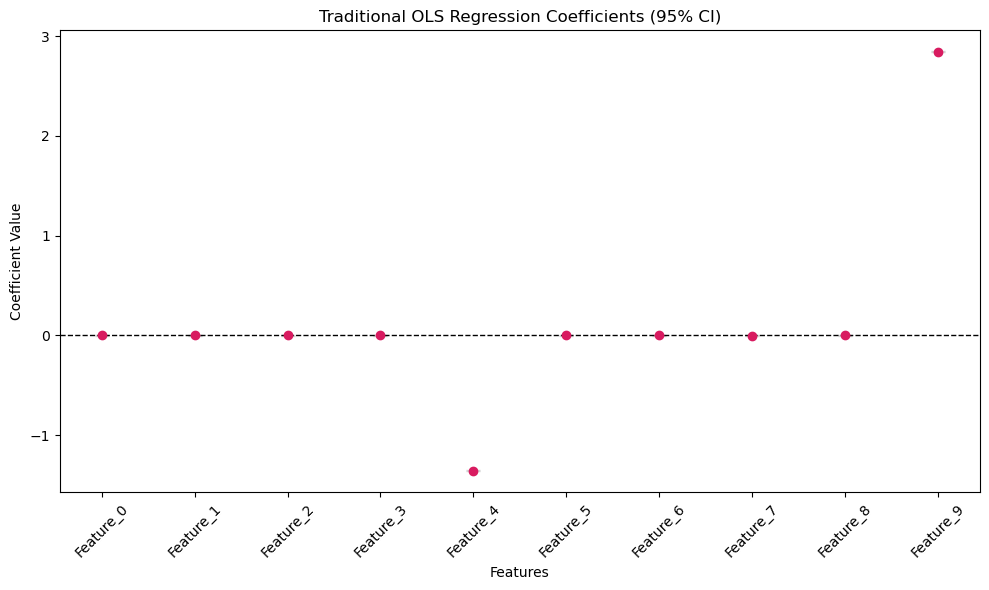


Statistically Significant Features (p < 0.05):
['Feature_4', 'Feature_9']


In [20]:

# 2. Traditional Baseline (OLS)
perform_traditional_regression(X_train, y_train)


### make a simple xgboost model for test 1

In [21]:

# 3. Machine Learning Modeling (XGBoost)
# We pass the pre-split data directly to ensure apples-to-apples comparison
model = xgb.XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.1)
model.fit(X_train, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

### look at XGBoost Native Importances

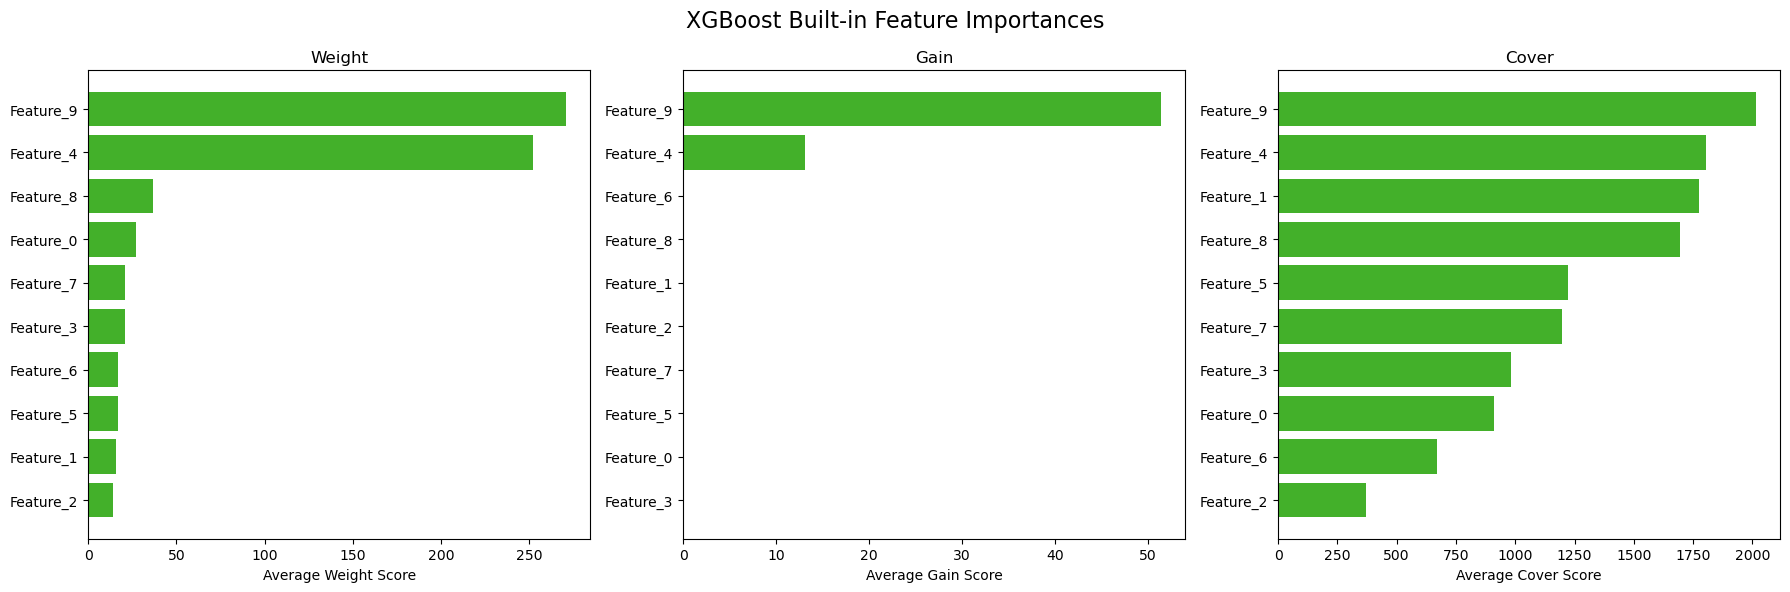

In [22]:

# 4. XGBoost Native Importances
plot_all_xgb_importances(model, feature_names)


### try to use SHAP to find the influencing inputs

In [23]:

# 5. Explainability (SHAP)
shap_values = compute_shap_values(model, X_train, X_test)


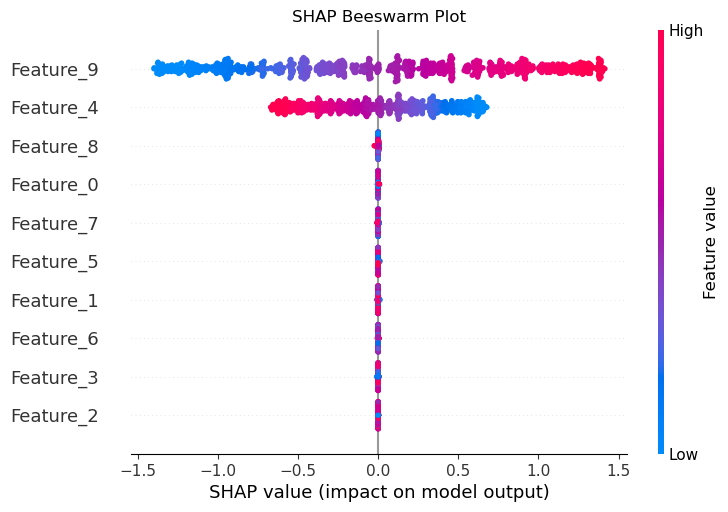

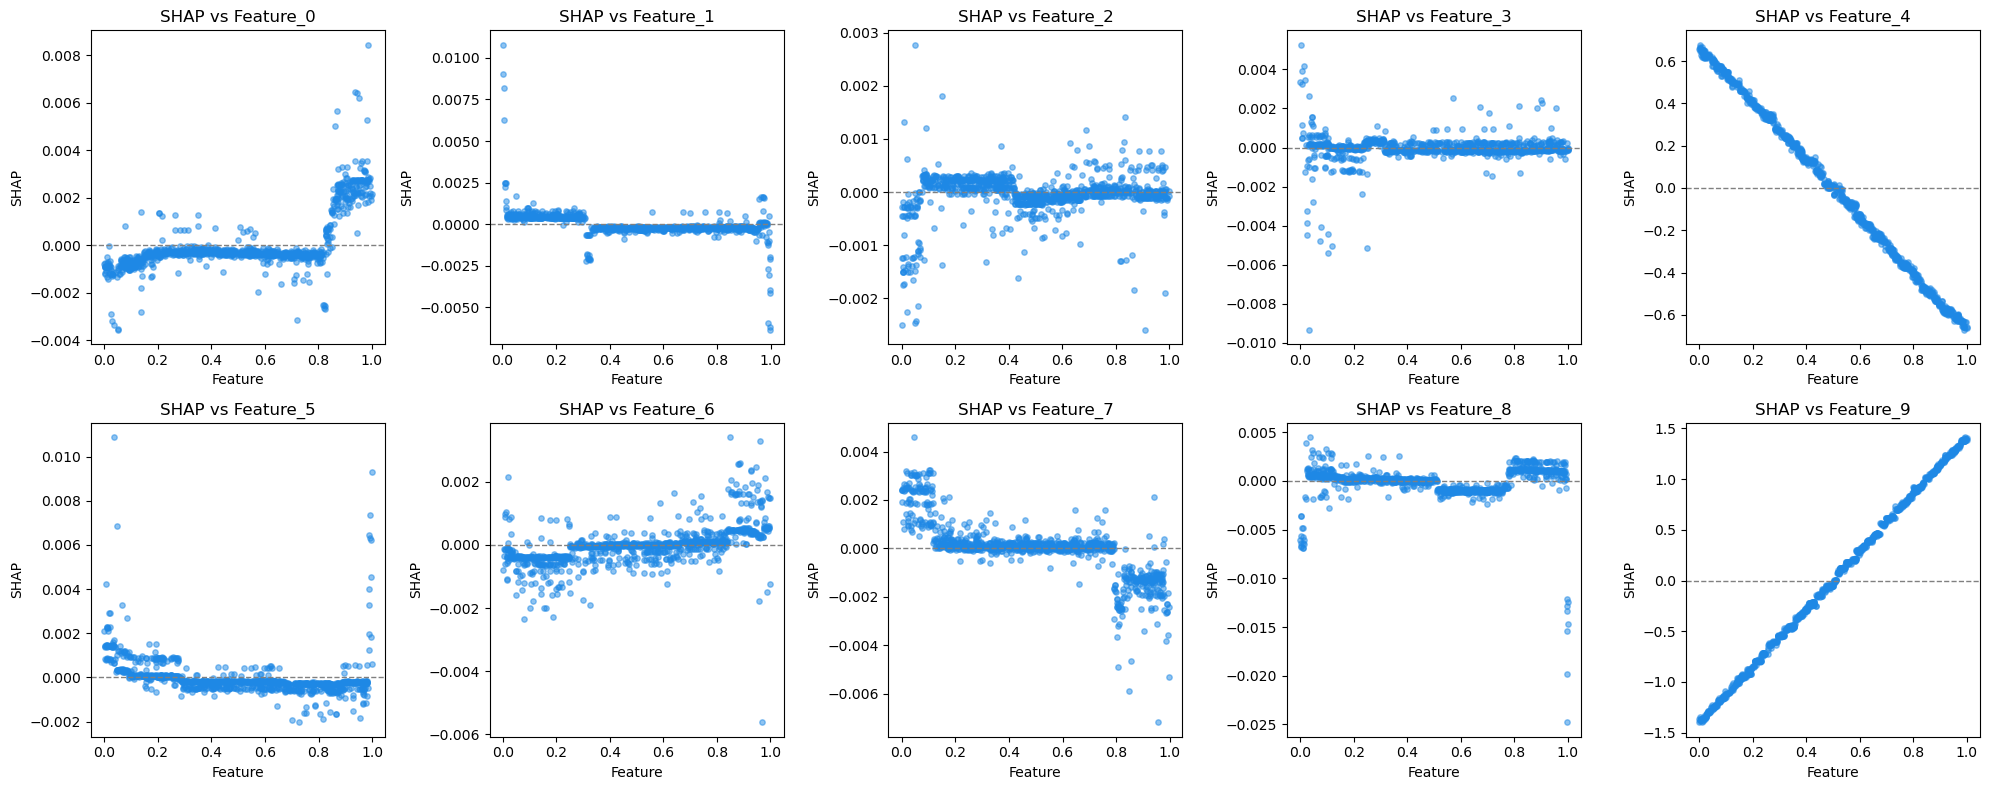

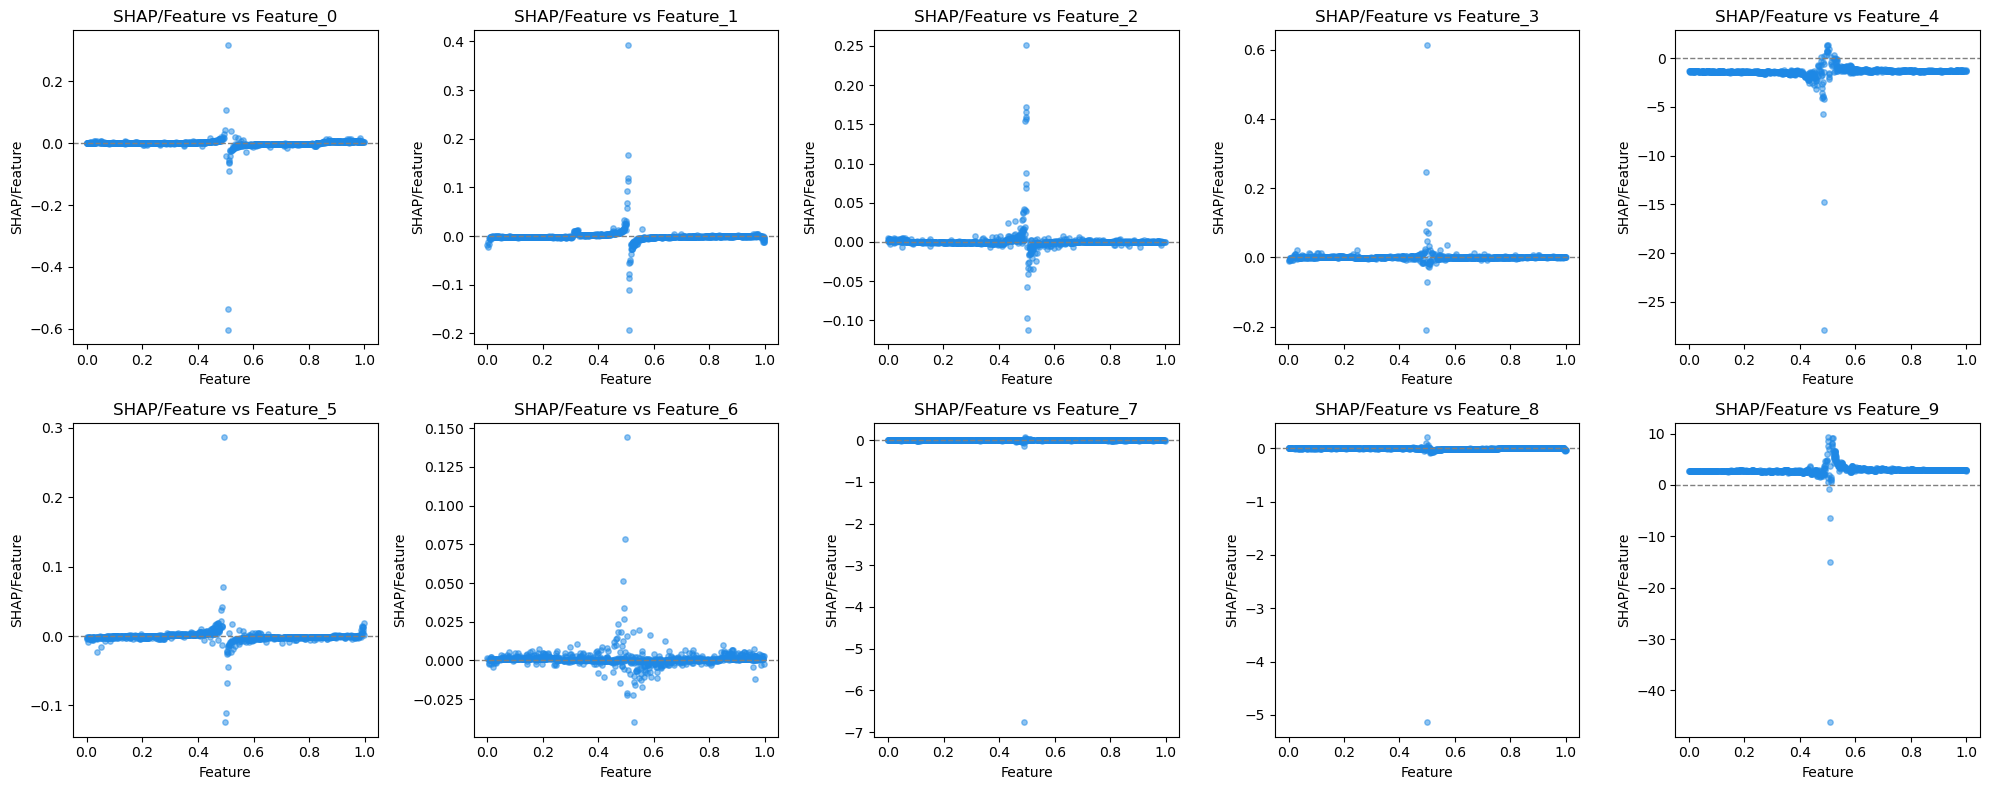

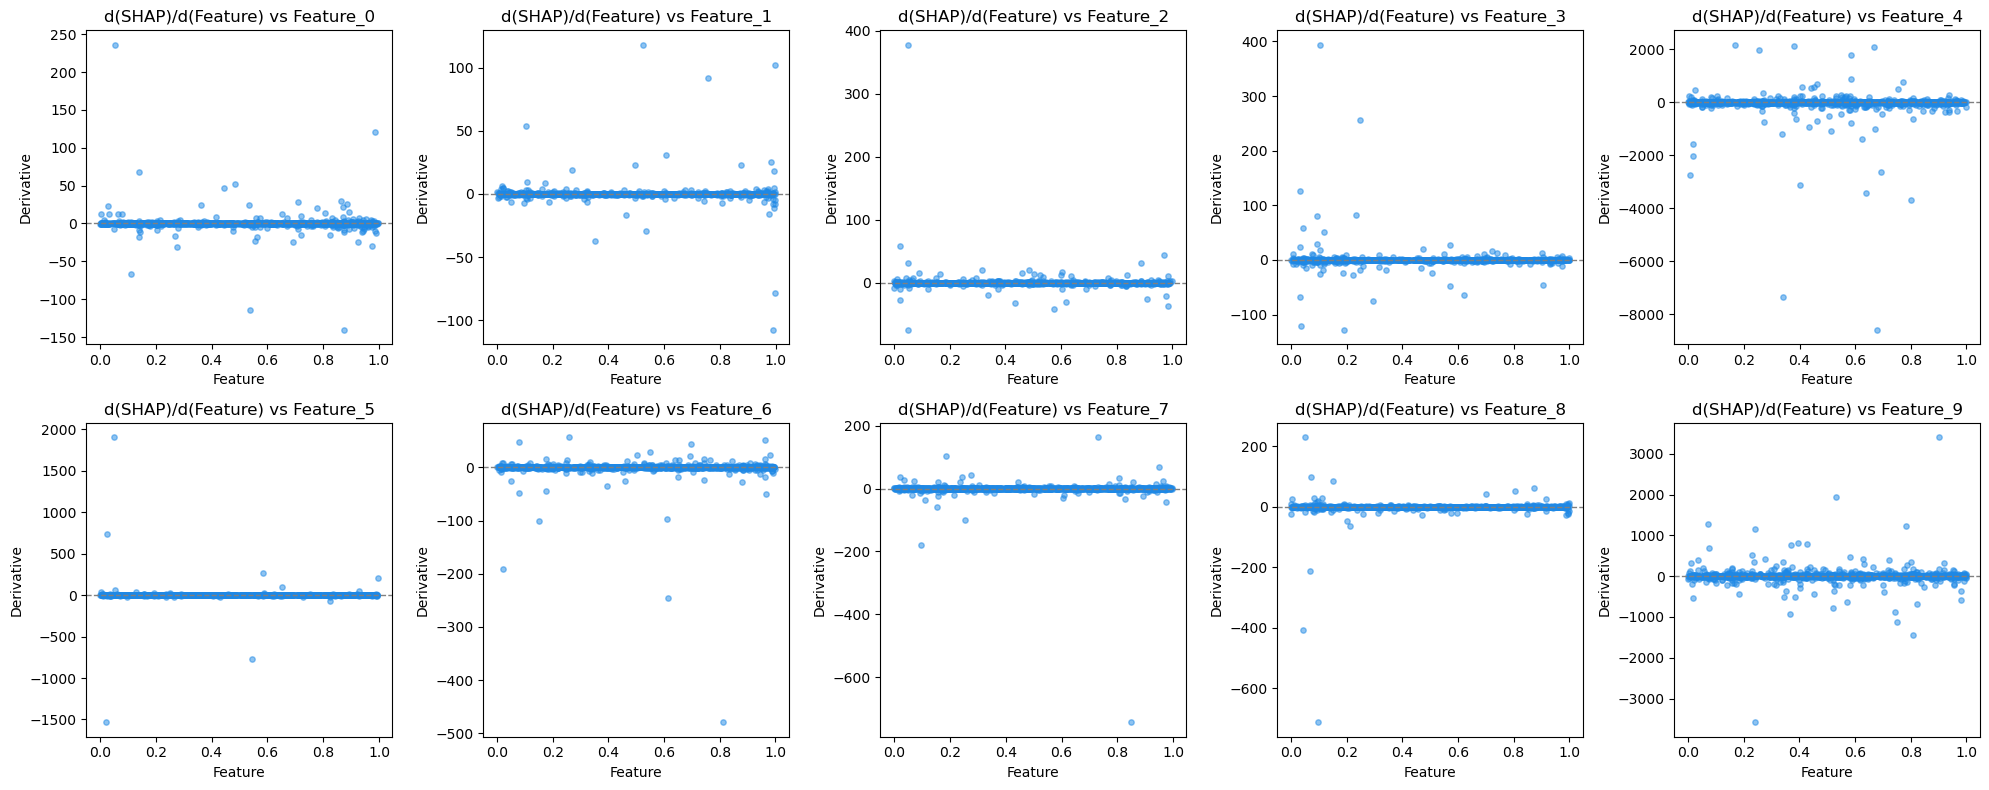

In [24]:

# 6. Visualization (SHAP)
plot_shap_analysis(shap_values, feature_names)


#### try to look for feature interactions
we shouldn't see any


--- Computing SHAP Interaction Values ---


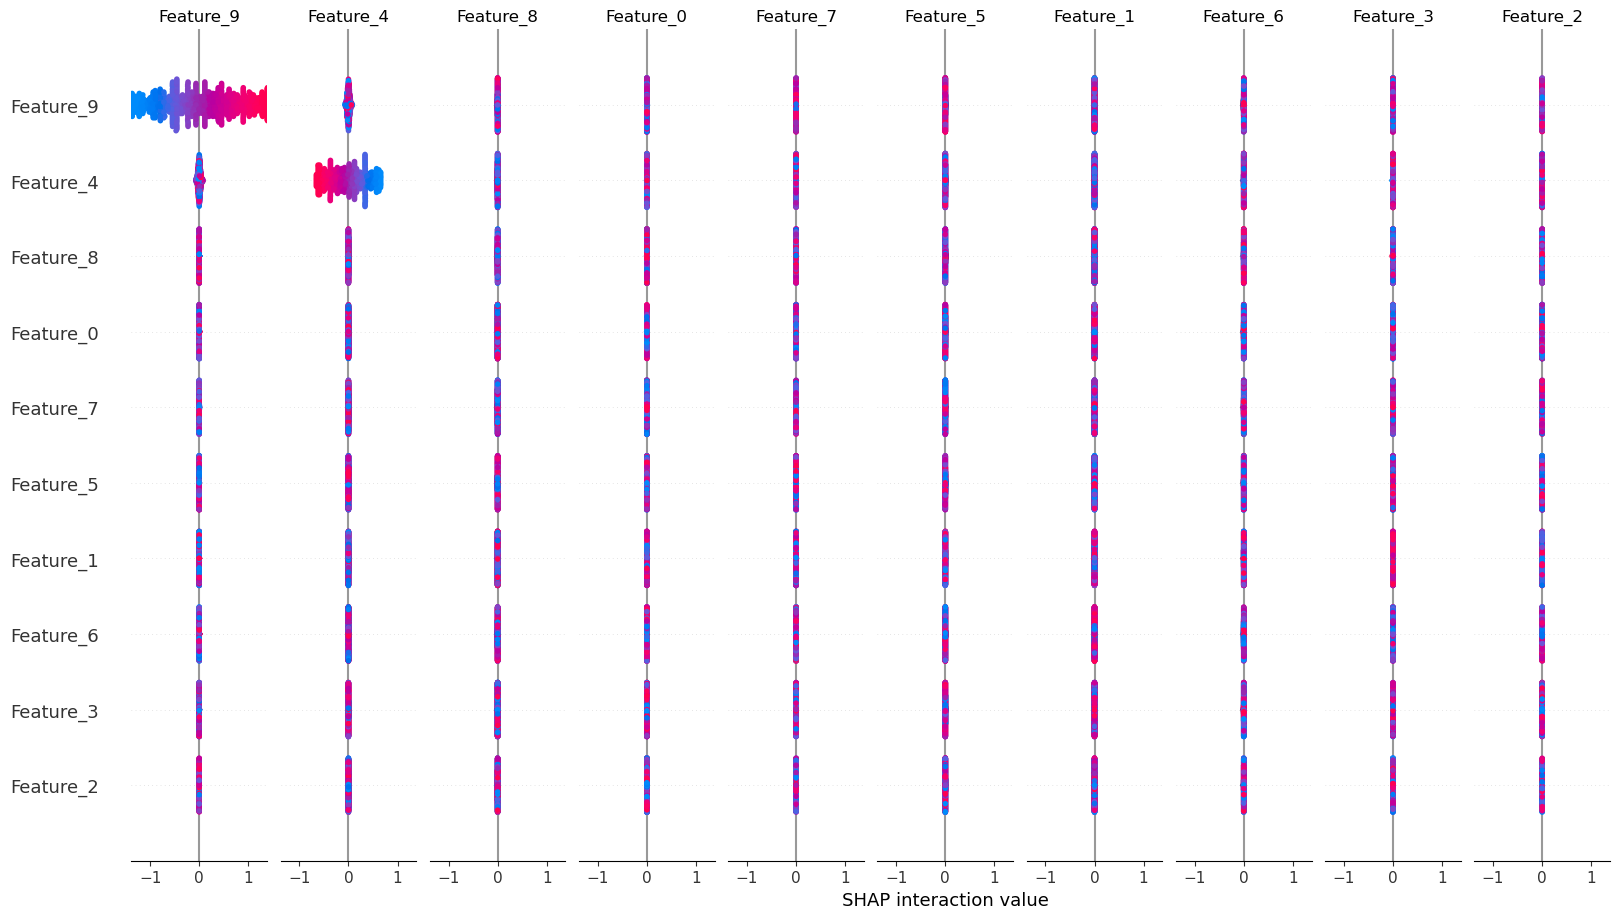


Strongest Interaction found by SHAP: Feature_4 & Feature_9
Plotting pure interaction effect for Feature_4 and Feature_9...


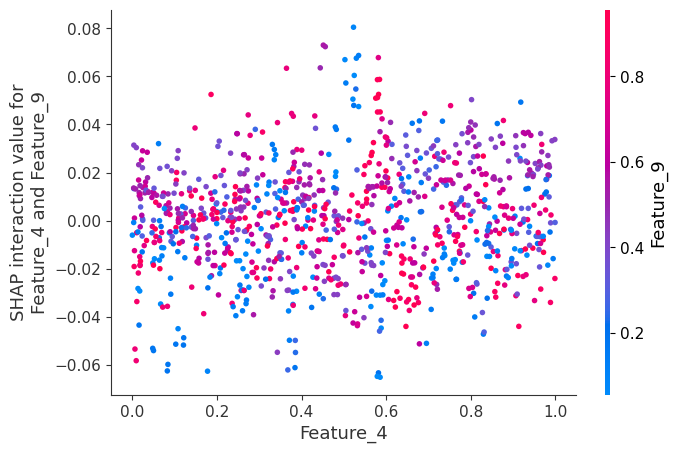

In [25]:

# 7. Deep Dive: SHAP Interaction Analysis
# Note: X_test must be a DataFrame or numpy array. We use X_test directly.
analyze_shap_interactions(model, X_test, feature_names)


#### SHAP summry

In [26]:

# 8. Summary (SHAP)
ranked_features = print_feature_importance(shap_values)



SHAP Global Importance Dictionary:
  Feature_9: 0.6938
  Feature_4: 0.3353
  Feature_8: 0.0010
  Feature_0: 0.0008
  Feature_7: 0.0007
  Feature_5: 0.0005
  Feature_1: 0.0004
  Feature_6: 0.0004
  Feature_3: 0.0003
  Feature_2: 0.0002

Ranked Features (Most to Least Important):
['Feature_9', 'Feature_4', 'Feature_8', 'Feature_0', 'Feature_7', 'Feature_5', 'Feature_1', 'Feature_6', 'Feature_3', 'Feature_2']


## test for linear combination with some feature interactions

### make example data 2

In [27]:

# 1. Setup & Data
X, y, feature_names = generate_synthetic_data_with_interactions(
    num_inputs=10, 
    num_samples=5000, 
    num_contributing_features=(2, 5), 
    weight_range=(-3, 3),
    num_interactions=(1, 2),
    interaction_weight_range=(-3, 3),
    noise_std=0.05,
)

# Split data here so both OLS and XGBoost train on the exact same subsets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


--- Generative Model Info (With Interactions) ---
Number of linear variables (M): 4
Number of interaction terms: 2

--- True Mathematical Equation ---
y = (-2.9990 * Feature_5) + (2.7625 * Feature_7) + (-2.2412 * Feature_6) + (0.8187 * Feature_4) + (-1.7551 * Feature_0 * Feature_2) + (-0.8987 * Feature_4 * Feature_6) + Noise(0, 0.05)
-------------------------------------------------



### make the Traditional Baseline (OLS)


--- Traditional Regression Analysis (OLS) ---
                            OLS Regression Results                            
Dep. Variable:              Feature_6   R-squared:                       0.987
Model:                            OLS   Adj. R-squared:                  0.987
Method:                 Least Squares   F-statistic:                 2.998e+04
Date:                Sun, 15 Mar 2026   Prob (F-statistic):               0.00
Time:                        15:28:13   Log-Likelihood:                 1390.2
No. Observations:                4000   AIC:                            -2758.
Df Residuals:                    3989   BIC:                            -2689.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const

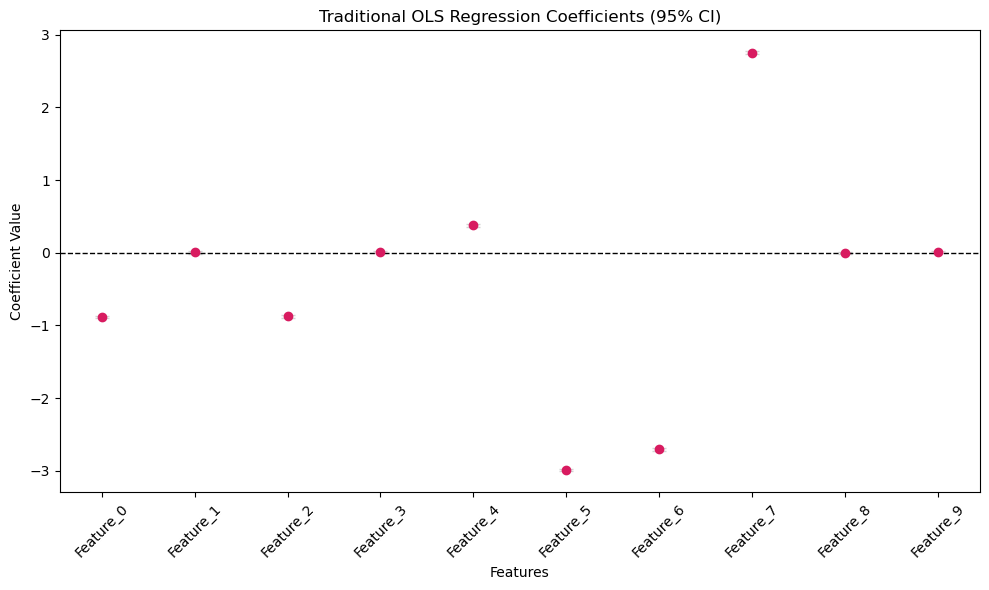


Statistically Significant Features (p < 0.05):
['Feature_0', 'Feature_2', 'Feature_4', 'Feature_5', 'Feature_6', 'Feature_7']


In [28]:

# 2. Traditional Baseline (OLS)
perform_traditional_regression(X_train, y_train)


### make a simple xgboost model for test 1

In [29]:

# 3. Machine Learning Modeling (XGBoost)
# We pass the pre-split data directly to ensure apples-to-apples comparison
model = xgb.XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.1)
model.fit(X_train, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

### look at XGBoost Native Importances

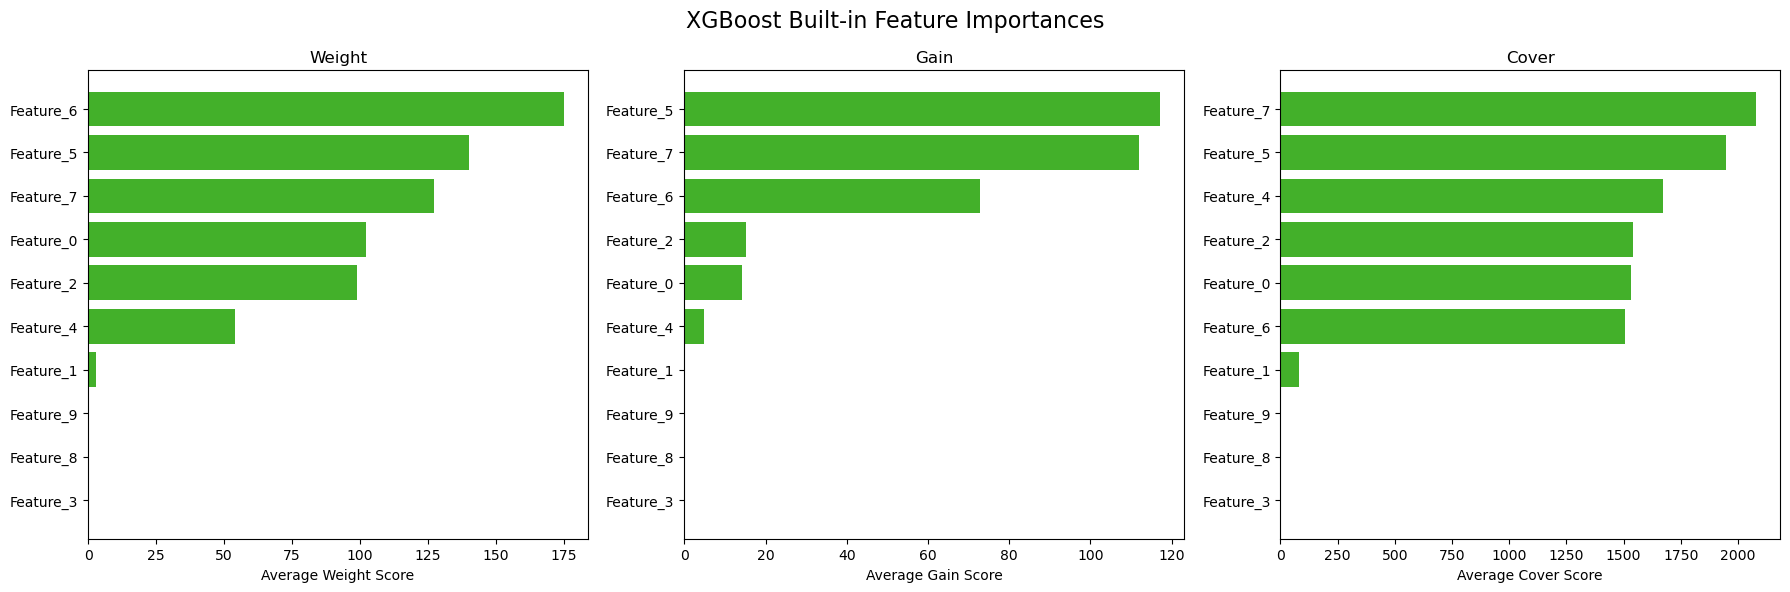

In [30]:

# 4. XGBoost Native Importances
plot_all_xgb_importances(model, feature_names)


### try to use SHAP to find the influencing inputs

In [31]:

# 5. Explainability (SHAP)
shap_values = compute_shap_values(model, X_train, X_test)


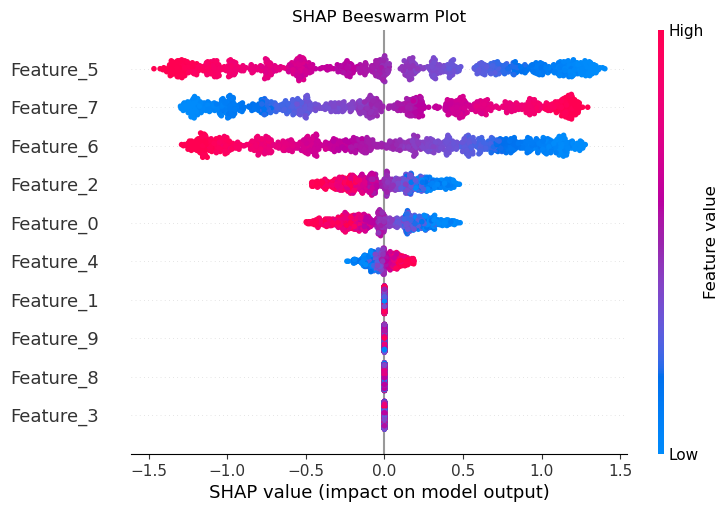

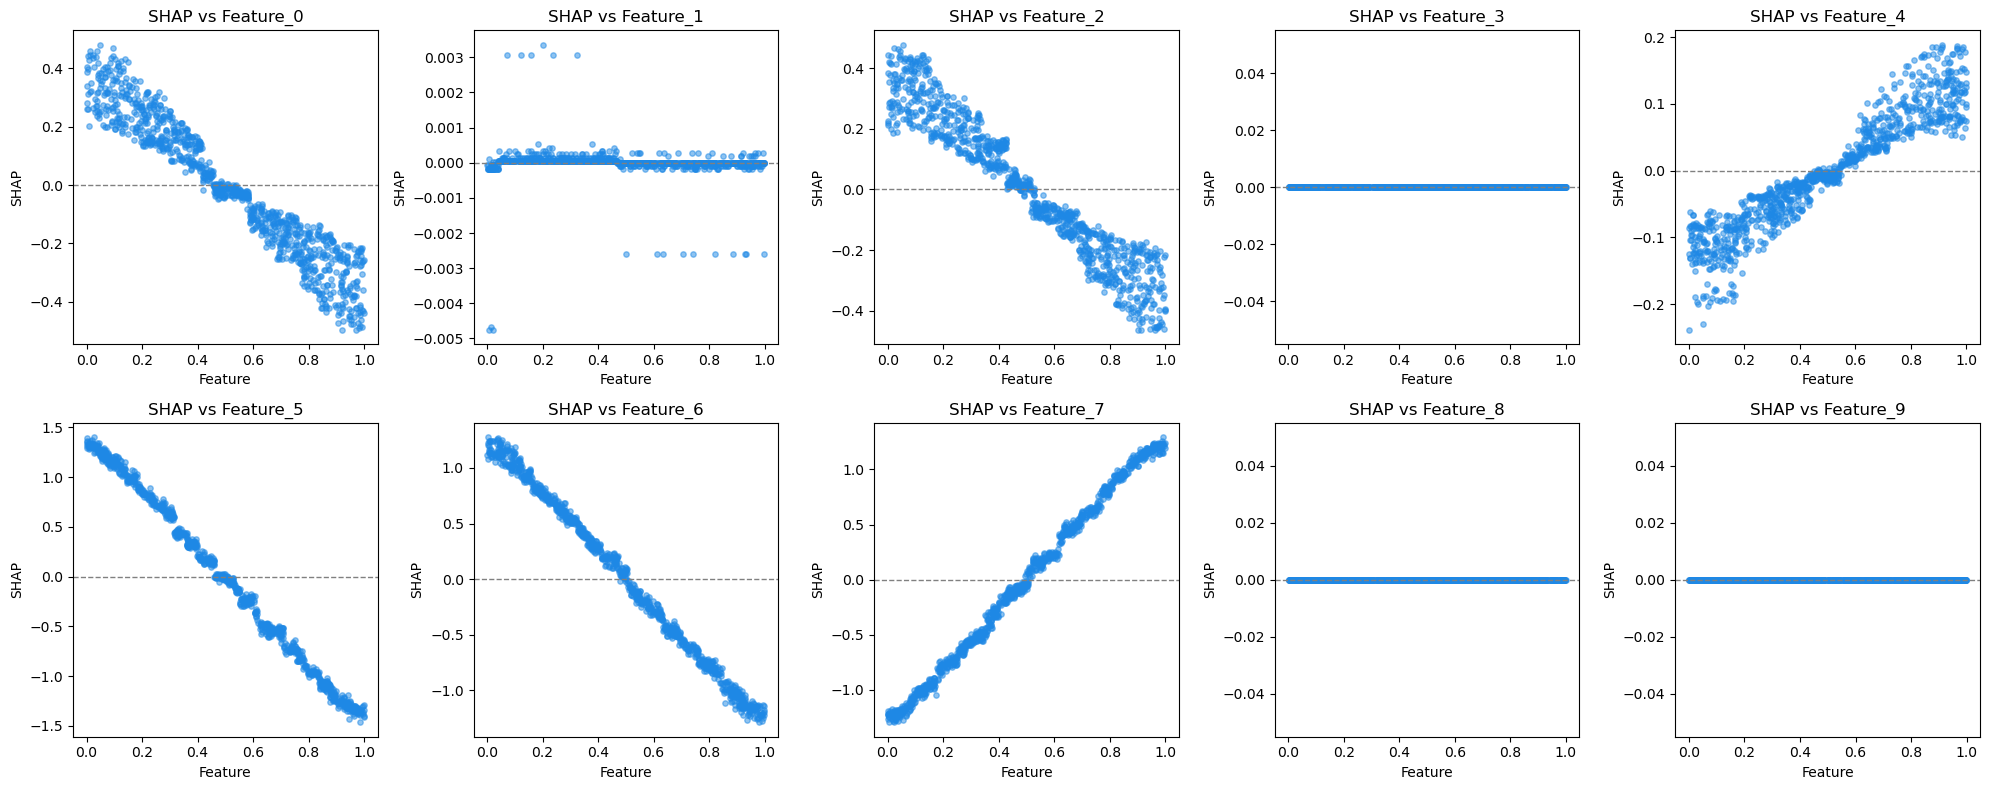

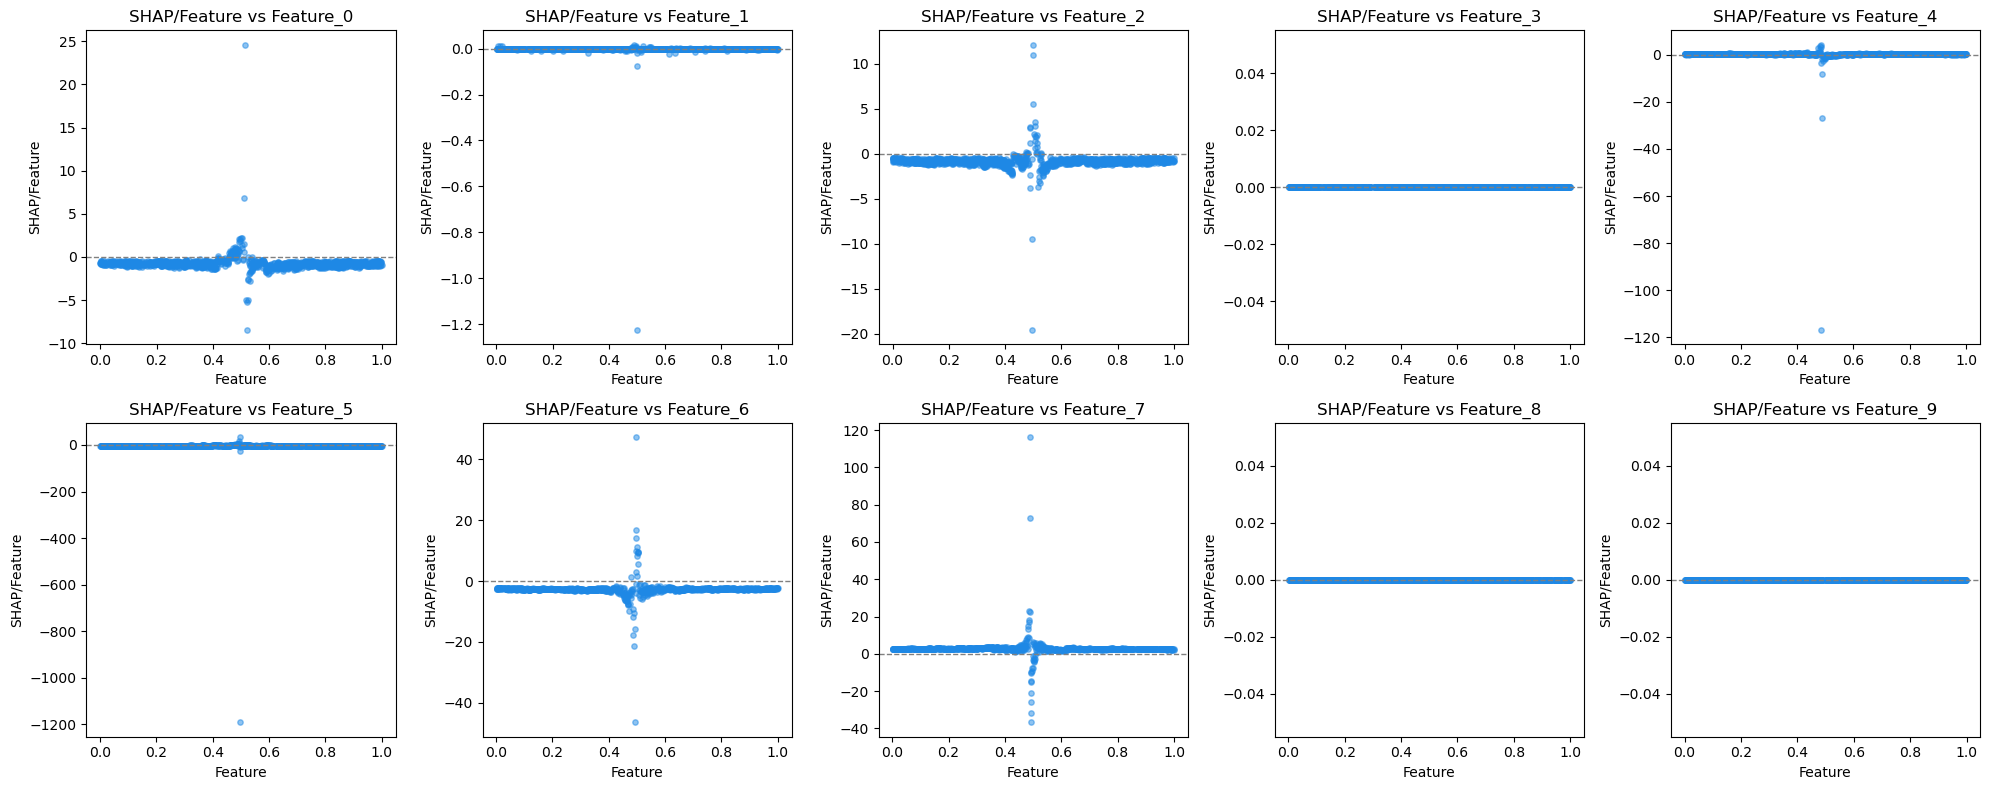

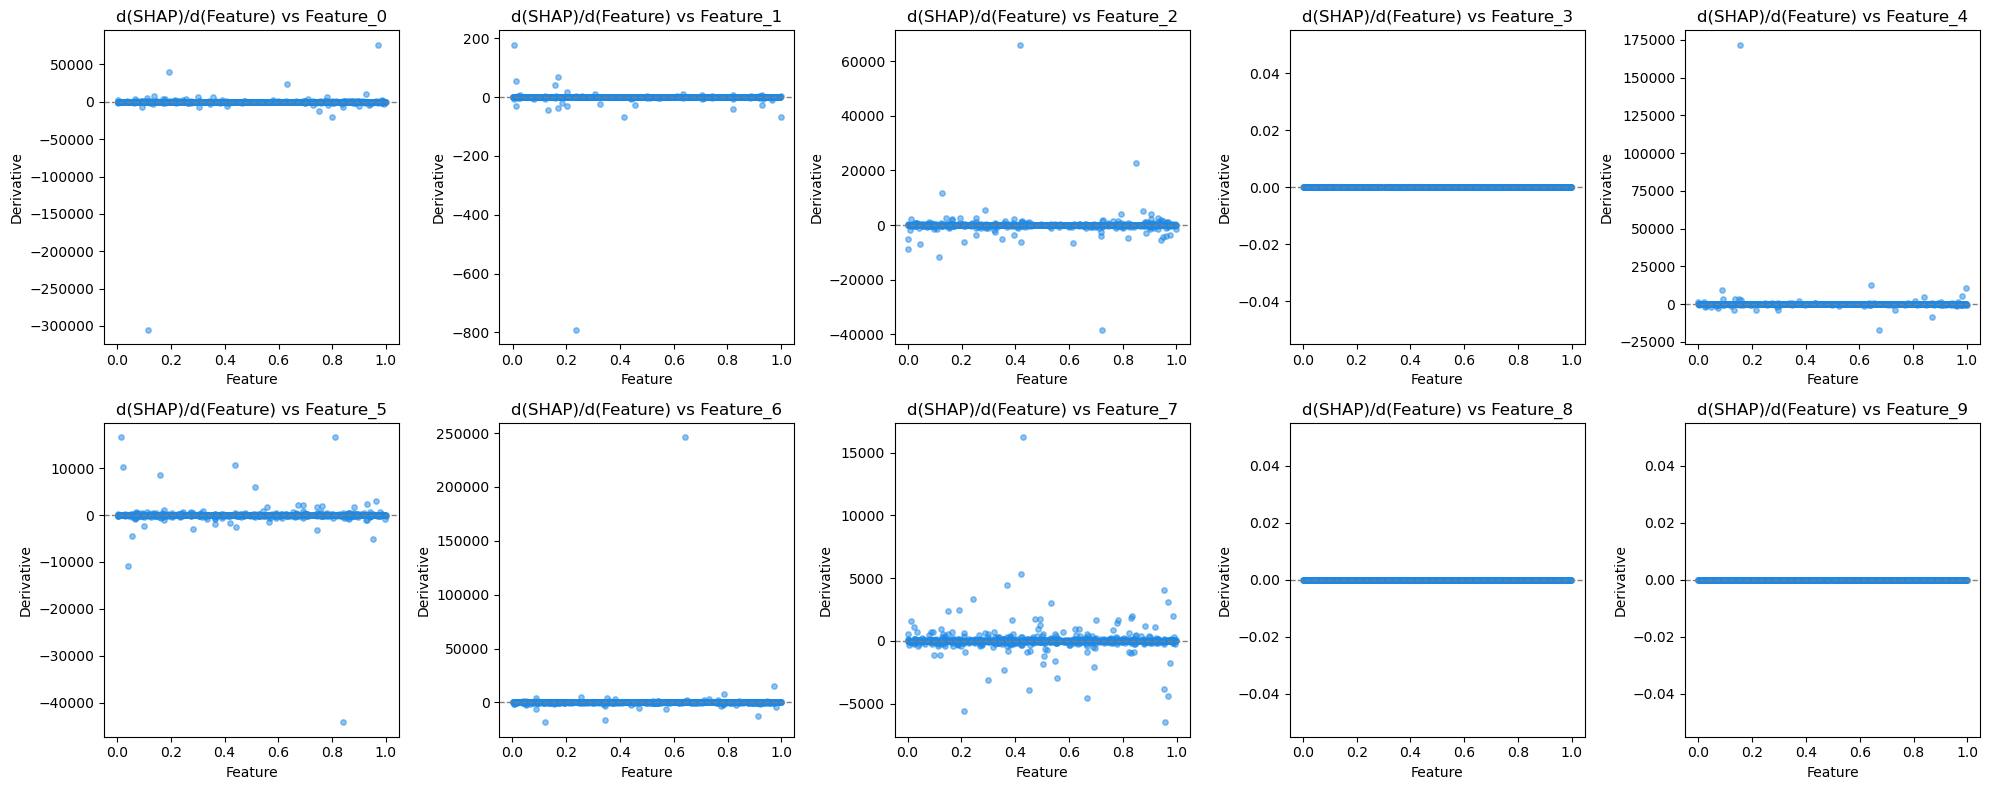

In [32]:

# 6. Visualization (SHAP)
plot_shap_analysis(shap_values, feature_names)


#### try to look for feature interactions
we should see some now


--- Computing SHAP Interaction Values ---


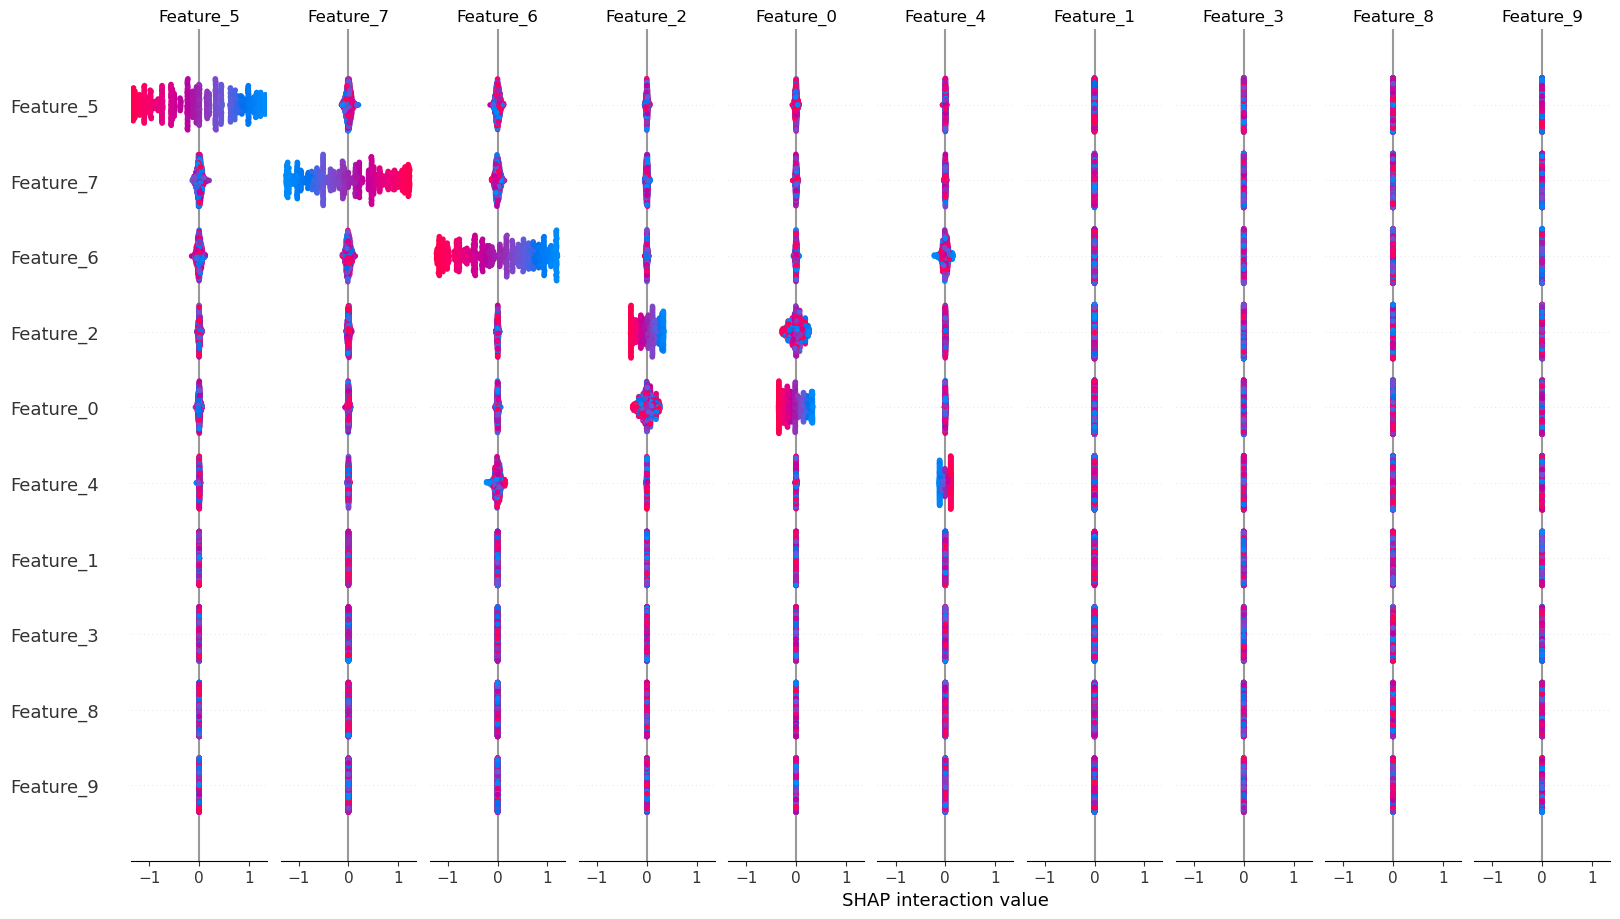


Strongest Interaction found by SHAP: Feature_0 & Feature_2
Plotting pure interaction effect for Feature_0 and Feature_2...


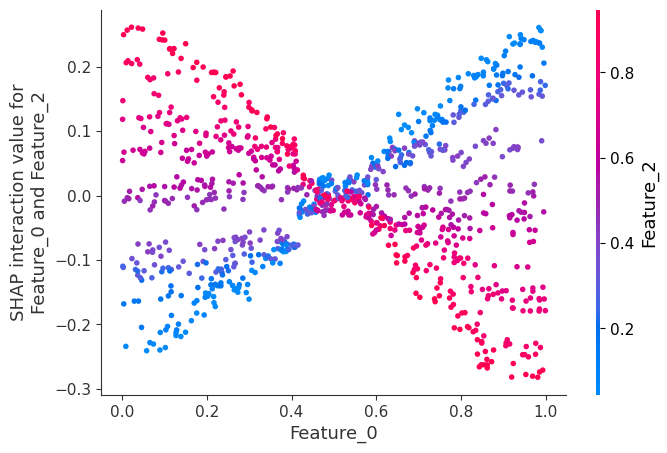

In [33]:

# 7. Deep Dive: SHAP Interaction Analysis
# Note: X_test must be a DataFrame or numpy array. We use X_test directly.
analyze_shap_interactions(model, X_test, feature_names)


#### SHAP summry

In [34]:

# 8. Summary (SHAP)
ranked_features = print_feature_importance(shap_values)



SHAP Global Importance Dictionary:
  Feature_5: 0.7295
  Feature_7: 0.6684
  Feature_6: 0.6618
  Feature_2: 0.2007
  Feature_0: 0.1999
  Feature_4: 0.0719
  Feature_1: 0.0001
  Feature_3: 0.0000
  Feature_8: 0.0000
  Feature_9: 0.0000

Ranked Features (Most to Least Important):
['Feature_5', 'Feature_7', 'Feature_6', 'Feature_2', 'Feature_0', 'Feature_4', 'Feature_1', 'Feature_3', 'Feature_8', 'Feature_9']


## test for addition of hidden features

### make example data 3

In [35]:

# 1. Setup & Data
X, hidden_featues, y, feature_names, hidden_feature_names = generate_synthetic_data_with_hidden_features(
    num_inputs = 10, 
    num_samples = 5000, 
    num_contributing_features = (2, 5), 
    num_hidden_features = (1, 2), 
    weight_range = (-3, 3), 
    num_interactions = (1, 2), 
    interaction_weight_range = (-3, 3), 
    noise_std = 0.05, 
    hidden_in_linear = True,           # Should hidden features have a linear impact?
    hidden_in_interactions = True,     # Should hidden features be part of interactions?
    )

# Split data here so both OLS and XGBoost train on the exact same subsets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


--- Generative Model Info (With HIDDEN Features) ---
Number of linear variables: 6 (5 visible, 1 hidden)
Number of interaction terms: 2

--- True Mathematical Equation ---
y = (2.9436 * Feature_1) + (-2.7909 * Feature_5) + (2.1836 * Feature_3) + (1.4855 * Feature_8) + (-1.3874 * Hidden_0) + (-0.3980 * Feature_4) + (1.9075 * Feature_3 * Hidden_0) + (0.2587 * Feature_3 * Feature_6) + Noise(0, 0.05)
----------------------------------------------------



### make the Traditional Baseline (OLS)


--- Traditional Regression Analysis (OLS) ---
                            OLS Regression Results                            
Dep. Variable:              Feature_5   R-squared:                       0.983
Model:                            OLS   Adj. R-squared:                  0.983
Method:                 Least Squares   F-statistic:                 2.296e+04
Date:                Sun, 15 Mar 2026   Prob (F-statistic):               0.00
Time:                        15:28:20   Log-Likelihood:                 582.86
No. Observations:                4000   AIC:                            -1144.
Df Residuals:                    3989   BIC:                            -1074.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const

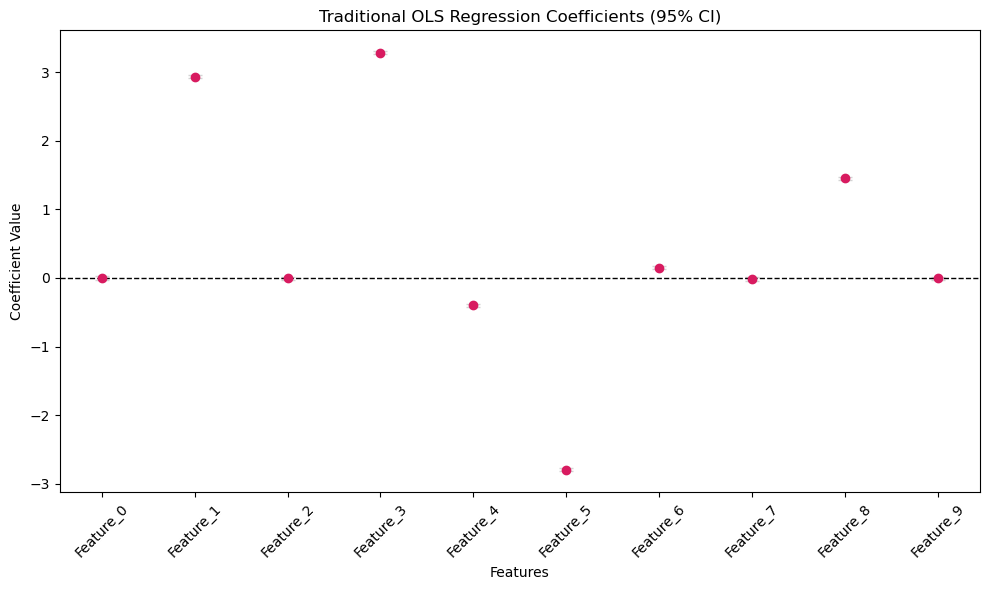


Statistically Significant Features (p < 0.05):
['Feature_1', 'Feature_3', 'Feature_4', 'Feature_5', 'Feature_6', 'Feature_8']


In [36]:

# 2. Traditional Baseline (OLS)
perform_traditional_regression(X_train, y_train)


### make a simple xgboost model for test 1

In [37]:

# 3. Machine Learning Modeling (XGBoost)
# We pass the pre-split data directly to ensure apples-to-apples comparison
model = xgb.XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.1)
model.fit(X_train, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

### look at XGBoost Native Importances

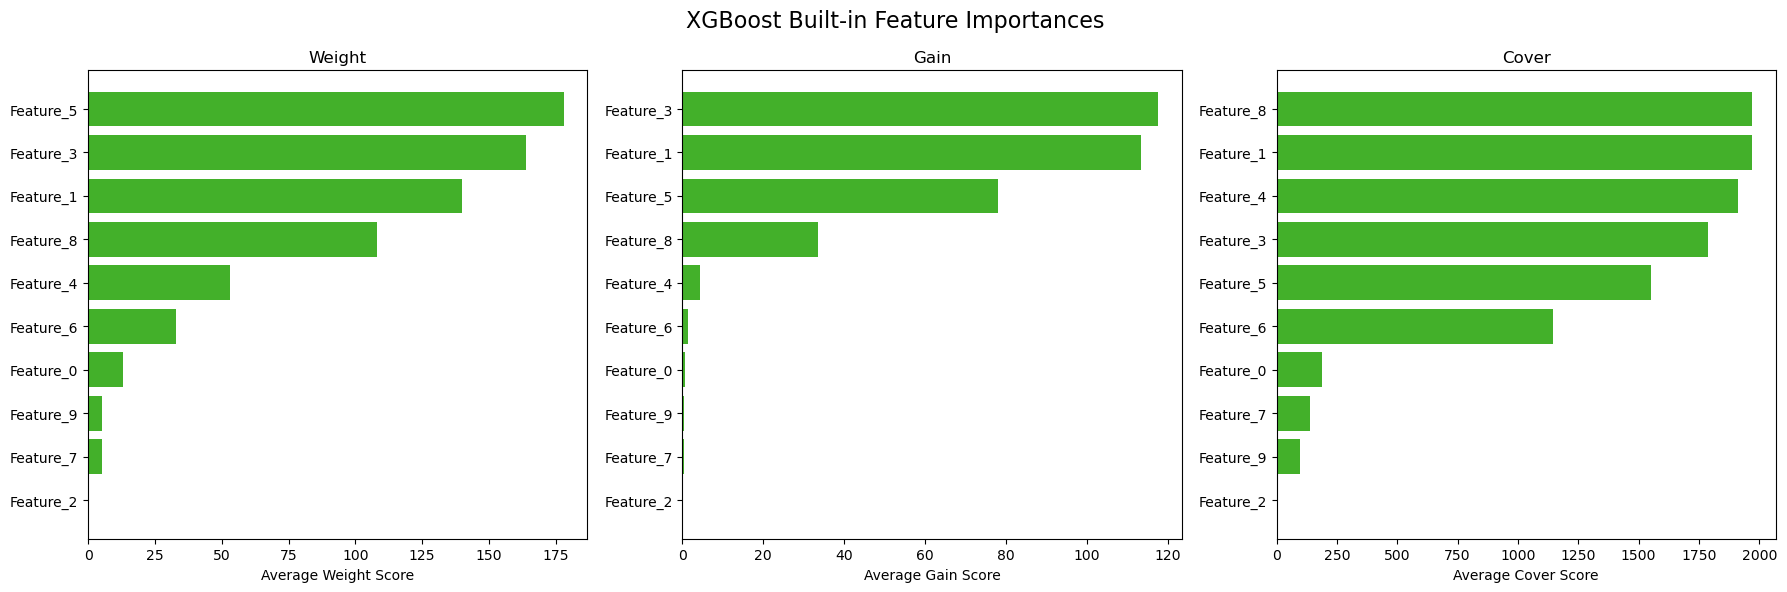

In [38]:

# 4. XGBoost Native Importances
plot_all_xgb_importances(model, feature_names)


### try to use SHAP to find the influencing inputs

In [39]:

# 5. Explainability (SHAP)
shap_values = compute_shap_values(model, X_train, X_test)


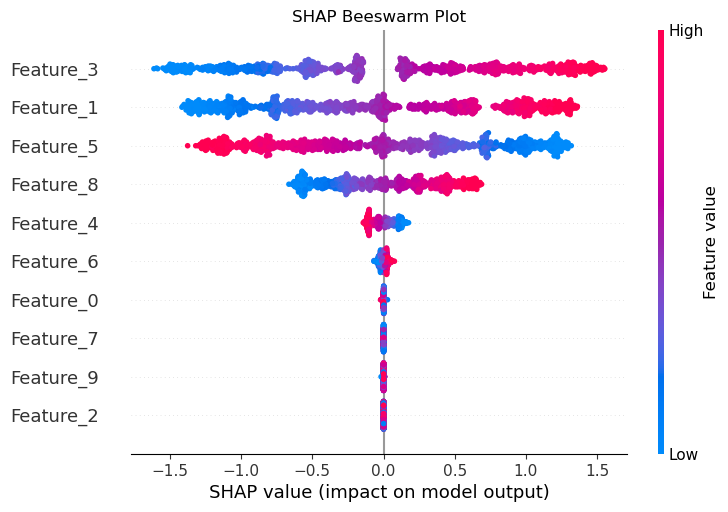

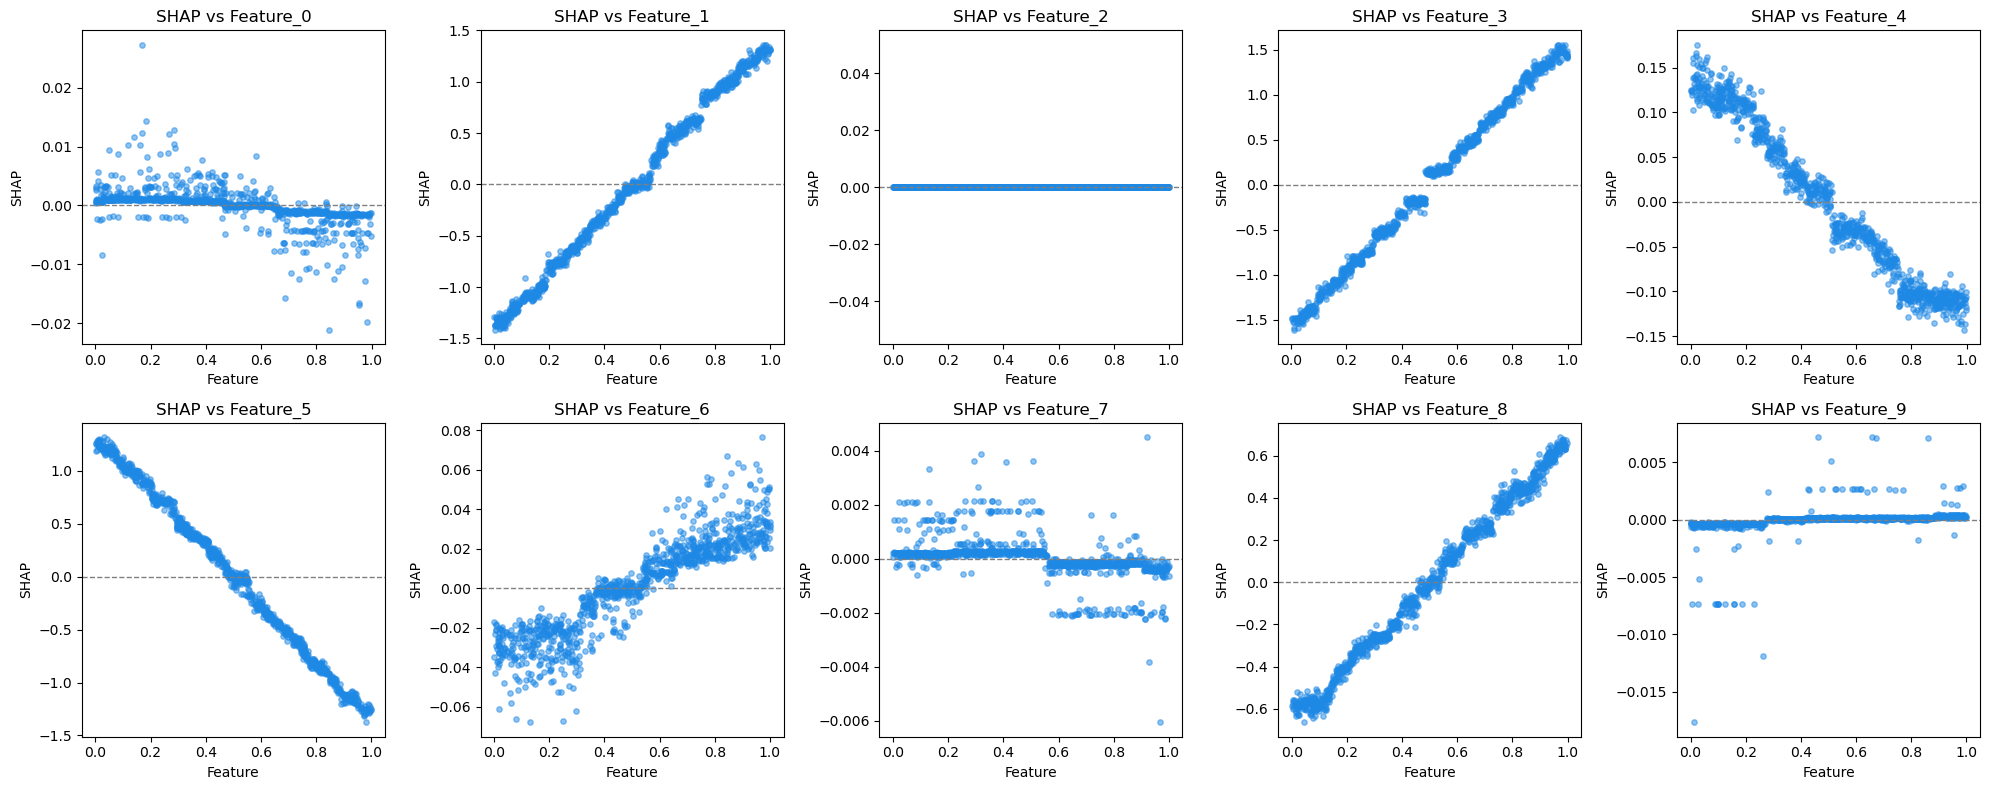

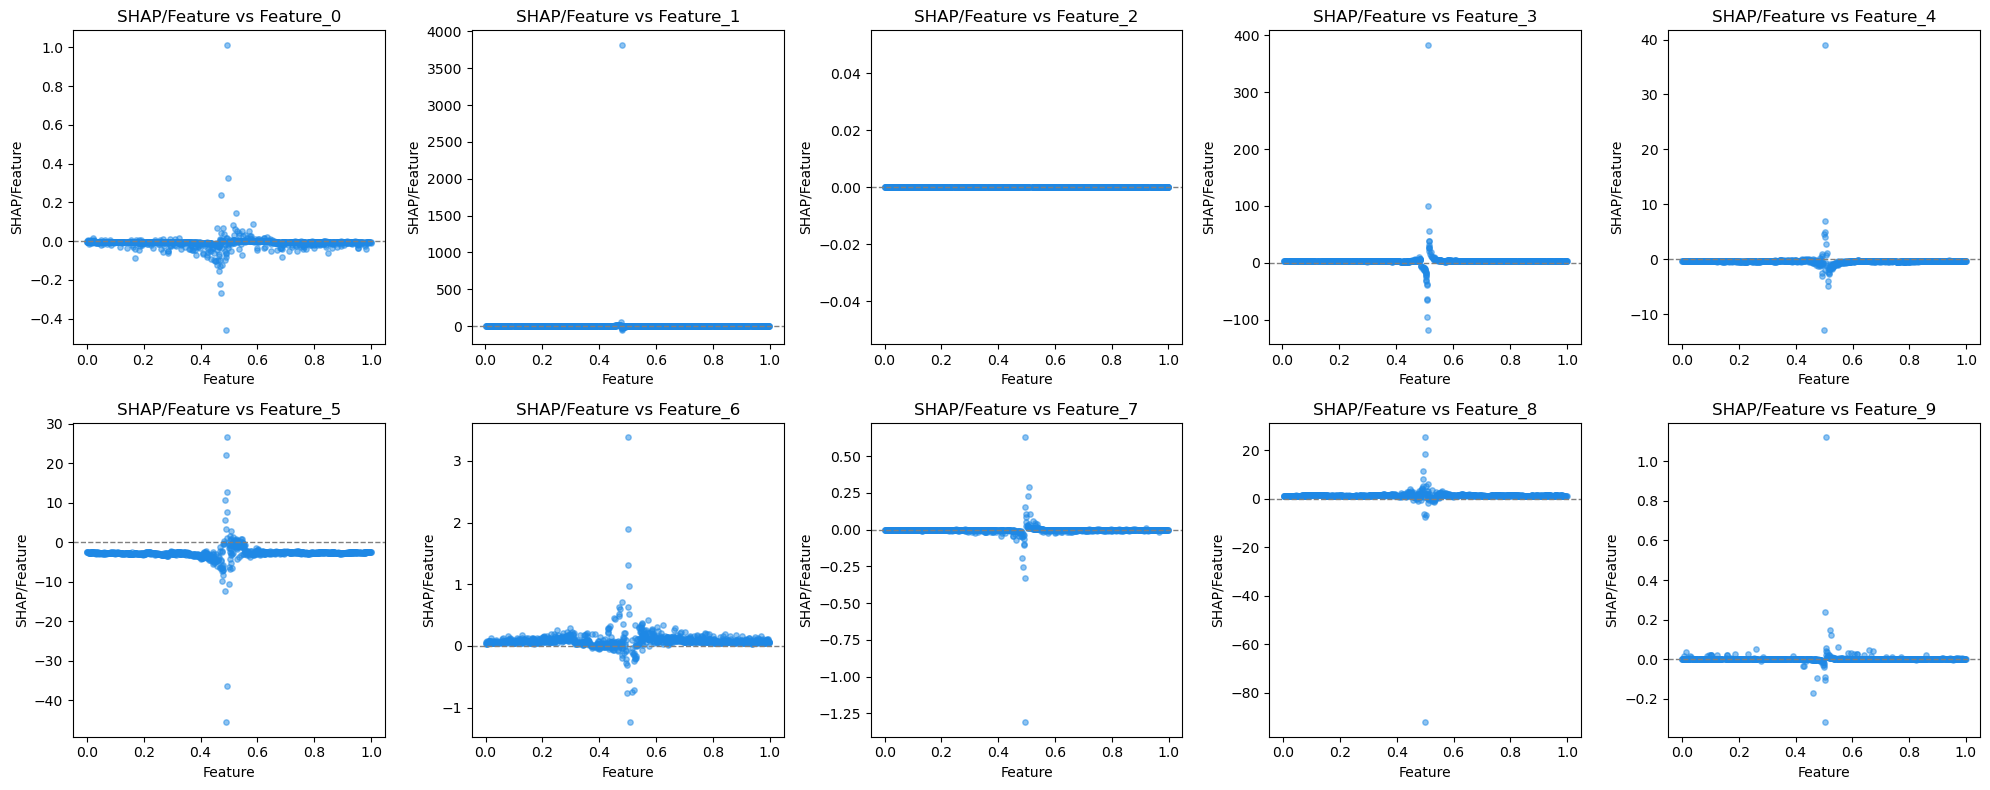

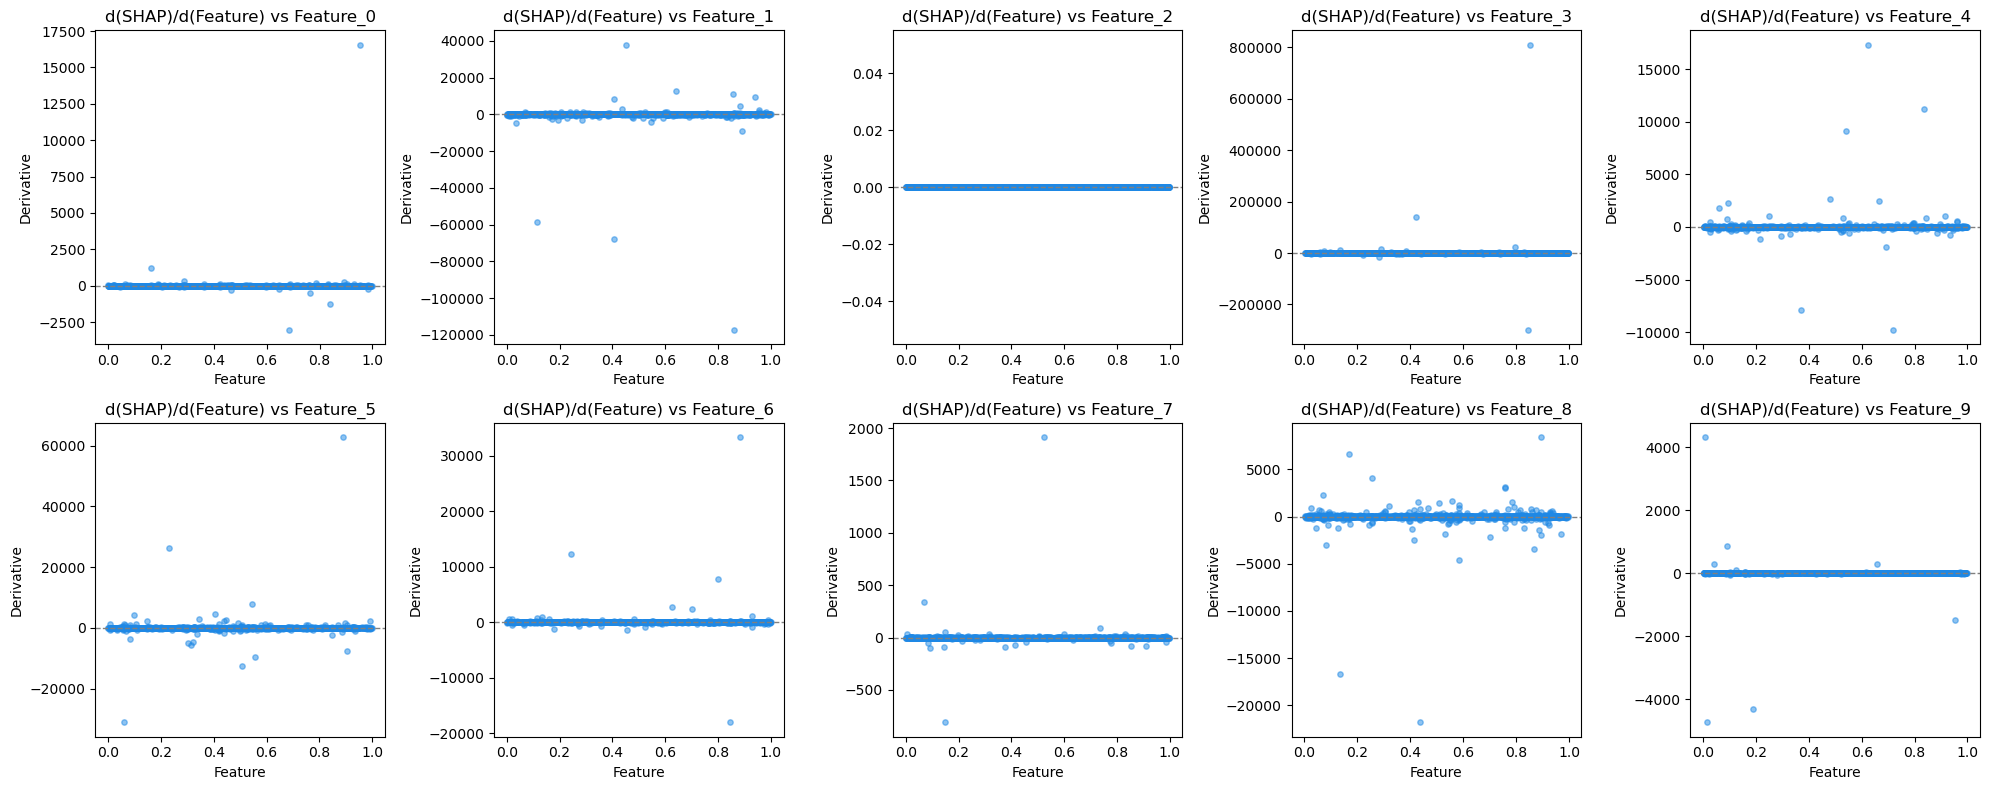

In [40]:

# 6. Visualization (SHAP)
plot_shap_analysis(shap_values, feature_names)


#### try to look for feature interactions
we should see some now


--- Computing SHAP Interaction Values ---


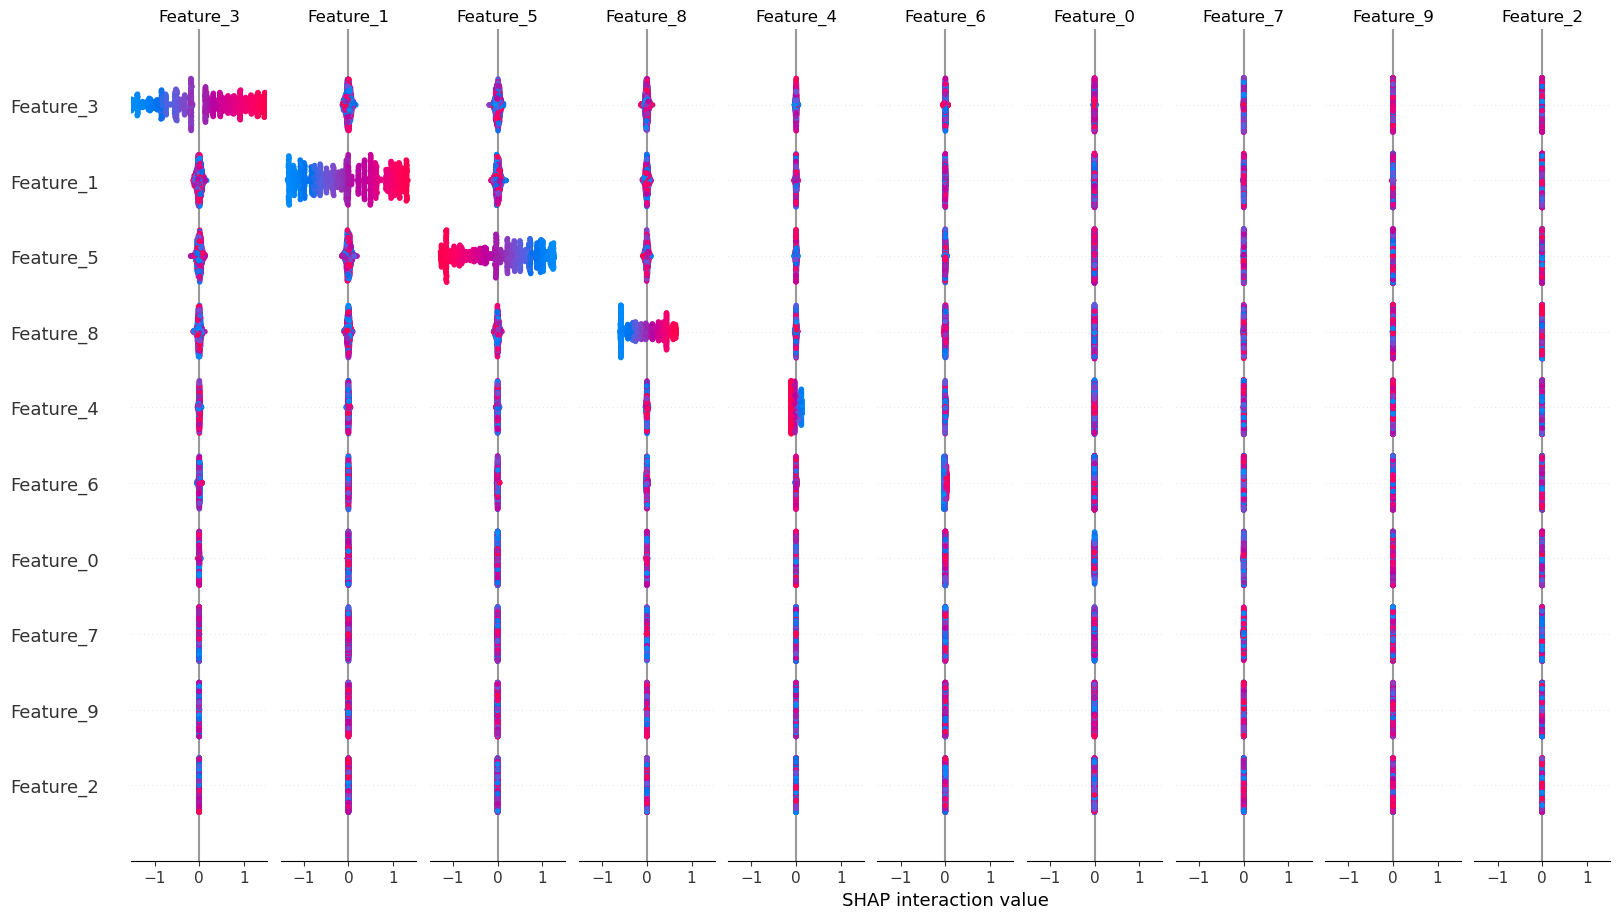


Strongest Interaction found by SHAP: Feature_1 & Feature_3
Plotting pure interaction effect for Feature_1 and Feature_3...


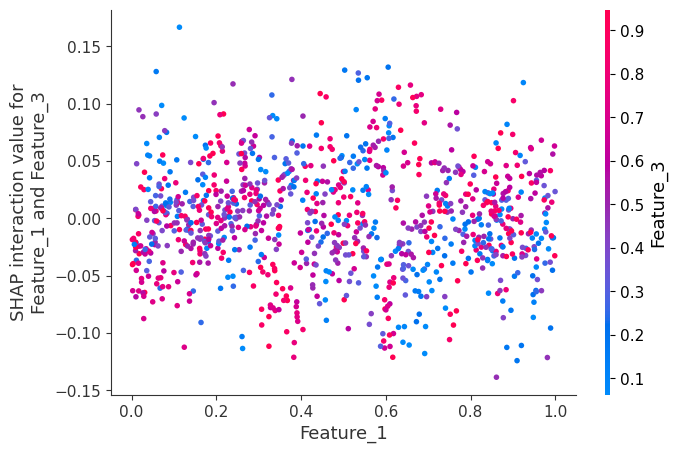

In [41]:

# 7. Deep Dive: SHAP Interaction Analysis
# Note: X_test must be a DataFrame or numpy array. We use X_test directly.
analyze_shap_interactions(model, X_test, feature_names)


#### SHAP summry

In [42]:

# 8. Summary (SHAP)
ranked_features = print_feature_importance(shap_values)



SHAP Global Importance Dictionary:
  Feature_3: 0.7871
  Feature_1: 0.7269
  Feature_5: 0.6646
  Feature_8: 0.3452
  Feature_4: 0.0774
  Feature_6: 0.0204
  Feature_0: 0.0019
  Feature_7: 0.0005
  Feature_9: 0.0004
  Feature_2: 0.0000

Ranked Features (Most to Least Important):
['Feature_3', 'Feature_1', 'Feature_5', 'Feature_8', 'Feature_4', 'Feature_6', 'Feature_0', 'Feature_7', 'Feature_9', 'Feature_2']
